# UNet Training on ROI Crops

In order to figure out if ROI detection is actually worth it, we train the model on the cropped dataset using the labeled boxes.

This notebook uses `ROIDataset` which automatically crops frames to the Region of Interest defined by the labeled bounding boxes.

In [1]:
# Colab setup: mount Drive, set project root, add src to path
import sys, os

# Install deps if running on Colab
if 'google.colab' in sys.modules:
    try:
        import torch, torchvision, cv2  # noqa: F401
    except Exception:
        %pip -q install torch torchvision opencv-python tqdm
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/AML-ETH-Project2'
else:
    # Fallback for local runs
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

SRC_PATH = os.path.join(PROJECT_ROOT, 'src')
if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

print('Project root:', PROJECT_ROOT)
print('Using src path:', SRC_PATH)

Mounted at /content/drive
Project root: /content/drive/MyDrive/AML-ETH-Project2
Using src path: /content/drive/MyDrive/AML-ETH-Project2/src


In [2]:
# Clear cached modules to force reimport of updated code
import sys
for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['dataset_bbox', 'train_bbox', 'BBoxRegressor', 'utils', 'dataset_ROI']):
        del sys.modules[mod]

print("✓ Module cache cleared - fresh import will happen next")

✓ Module cache cleared - fresh import will happen next


In [3]:
# Load data
from utils.utilities import load_zipped_pickle, make_train_test_split
import numpy as np

DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'raw', 'train.pkl')
data = load_zipped_pickle(DATA_PATH)

print(f'Number of samples: {len(data)}')

Number of samples: 65


In [4]:
# Split data: train on mixed, validate on expert only (matches test distribution)
expert = [d for d in data if d.get('dataset') == 'expert']
amateur = [d for d in data if d.get('dataset') == 'amateur']

rng = np.random.RandomState(42)
perm = rng.permutation(len(expert))
n_val = max(1, int(len(expert) * 0.2))
val_data = [expert[i] for i in perm[:n_val]]
train_data = [expert[i] for i in perm[n_val:]] + amateur

print(f"Train: expert={len(train_data)-len(amateur)}, amateur={len(amateur)} | Val: expert={len(val_data)}")
print(f"Total training samples: {len(train_data)}")
print(f"Total validation samples: {len(val_data)}")

Train: expert=16, amateur=46 | Val: expert=3
Total training samples: 62
Total validation samples: 3


In [5]:
# Create ROI datasets (crops images to bounding box)
from dataset_ROI import ROIDataset
from torch.utils.data import DataLoader
import torch

train_dataset = ROIDataset(train_data, target_size=(256, 256), augment=False)
val_dataset = ROIDataset(val_data, target_size=(256, 256), augment=False)

print(f'Training Dataset size: {len(train_dataset)}')
print(f'Validation Dataset size: {len(val_dataset)}')

# Check sample
sample = train_dataset[0]
print(f"\nSample output:")
print(f"  image shape: {sample[0].shape}")  # (1, 256, 256)
print(f"  label shape: {sample[1].shape}")  # (256, 256)

Training Dataset size: 186
Validation Dataset size: 9

Sample output:
  image shape: torch.Size([1, 256, 256])
  label shape: torch.Size([256, 256])


In [6]:
# Create DataLoaders
pin_mem = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0, pin_memory=pin_mem)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0, pin_memory=pin_mem)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')

Train batches: 24
Val batches: 2


=== Batch Structure ===
Image shape: torch.Size([8, 1, 256, 256])
Image dtype: torch.float32
Image min: 0.000, max: 0.999

Label shape: torch.Size([8, 256, 256])
Label dtype: torch.int64
Label unique values: [0, 1]


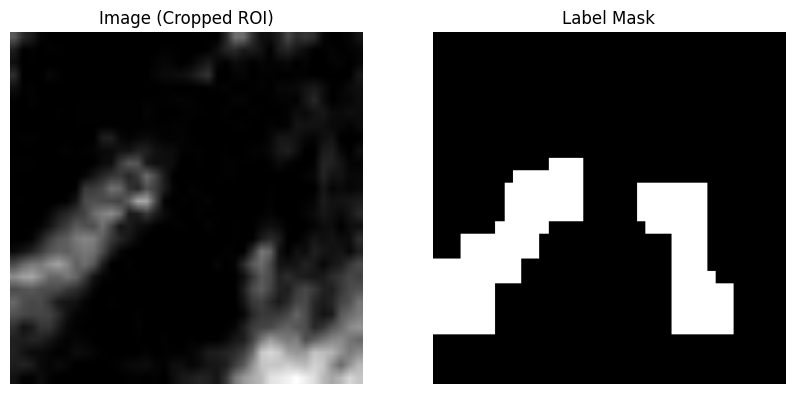

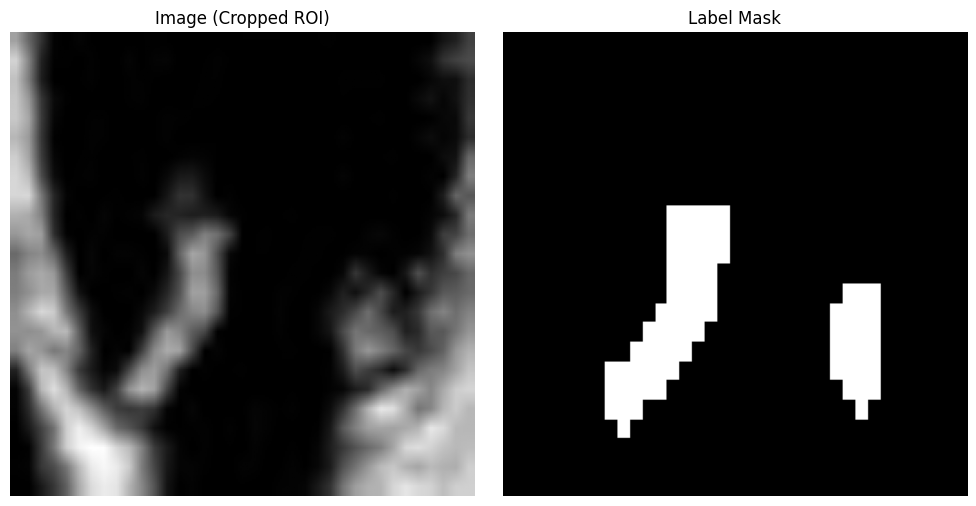

In [7]:
# Inspect a batch from train_loader
batch = next(iter(train_loader))

# batch is a tuple: (images, labels)
imgs, labels = batch

print("=== Batch Structure ===")
print(f"Image shape: {imgs.shape}")
print(f"Image dtype: {imgs.dtype}")
print(f"Image min: {imgs.min():.3f}, max: {imgs.max():.3f}")

print(f"\nLabel shape: {labels.shape}")
print(f"Label dtype: {labels.dtype}")
print(f"Label unique values: {torch.unique(labels).tolist()}")

# Visualize a sample from the batch
import matplotlib.pyplot as plt



def visualize_image(img,label):
  fig, axes = plt.subplots(1, 2, figsize=(10, 5))
  axes[0].imshow(img, cmap='gray')
  axes[0].set_title('Image (Cropped ROI)')
  axes[0].axis('off')

  axes[1].imshow(label, cmap='gray')
  axes[1].set_title('Label Mask')
  axes[1].axis('off')

visualize_image(imgs[0, 0].numpy(), labels[0].numpy())
visualize_image(imgs[1, 0].numpy(), labels[1].numpy())

plt.tight_layout()
plt.show()

In [8]:
# Setup model, optimizer, criterion
from models.UNet import UNet, initialize_weights
import torch.nn as nn

model = UNet(n_channels=1, n_classes=2)
initialize_weights(model)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

Using device: cuda


Overall Training:   0%|          | 0/30 [00:00<?, ?it/s]

Training next epoch:   0%|          | 0/24 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Overall Training:   3%|▎         | 1/30 [00:15<07:38, 15.82s/it, train_loss=0.314, val_loss=0.593]

Epoch 1/30 — train_loss: 0.314466, val_loss: 0.592551


...

Training next epoch:   0%|          | 0/24 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Overall Training: 100%|██████████| 30/30 [08:12<00:00, 16.42s/it, train_loss=0.0847, val_loss=0.19]

Epoch 30/30 — train_loss: 0.084723, val_loss: 0.189519


✓ Model saved to /content/drive/MyDrive/AML-ETH-Project2/weights/unet_roi_best.pth


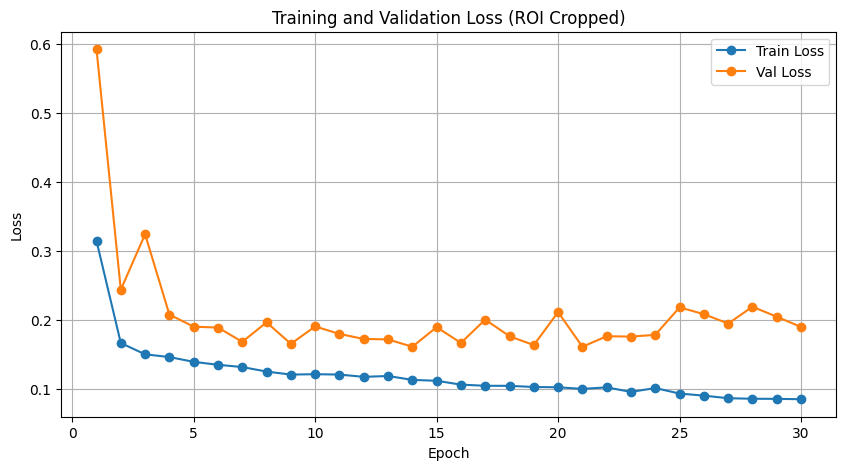

In [9]:
# Training loop
from train import train_one_epoch, eval_one_epoch
from tqdm import tqdm
import matplotlib.pyplot as plt

TRAIN = True  # Set to False to load pretrained weights
EPOCHS = 30

if TRAIN:
    train_losses = []
    val_losses = []

    pbar = tqdm(range(1, EPOCHS + 1), desc='Overall Training')
    for epoch in pbar:
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = eval_one_epoch(model, val_loader, criterion, device)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f'Epoch {epoch}/{EPOCHS} — train_loss: {train_loss:.6f}, val_loss: {val_loss:.6f}')
        pbar.set_postfix({'train_loss': train_loss, 'val_loss': val_loss})

    # Save model
    save_path = os.path.join(PROJECT_ROOT, 'weights', 'unet_roi_best.pth')
    torch.save(model.state_dict(), save_path)
    print(f'✓ Model saved to {save_path}')

    # Plot losses
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, EPOCHS + 1), train_losses, marker='o', label='Train Loss')
    plt.plot(range(1, EPOCHS + 1), val_losses, marker='o', label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss (ROI Cropped)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    # Load pretrained weights
    weights_path = os.path.join(PROJECT_ROOT, 'weights', 'unet_roi_best.pth')
    model.load_state_dict(torch.load(weights_path, map_location=device))
    print(f'✓ Model loaded from {weights_path}')

In [11]:
# Evaluate: Compute median IoU on validation set
import numpy as np

model.eval()
iou_scores = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc='Evaluating'):
        imgs = batch[0].to(device)
        masks = batch[1].to(device)

        logits = model(imgs)
        preds = torch.argmax(torch.softmax(logits, dim=1), dim=1)  # (B, H, W)

        # Compute IoU per sample
        for pred, target in zip(preds, masks):
            pred_bin = pred.bool()
            target_bin = target.bool()
            inter = (pred_bin & target_bin).sum().item()
            union = (pred_bin | target_bin).sum().item()
            iou = inter / union if union > 0 else 1.0
            iou_scores.append(iou)

median_iou = float(np.median(iou_scores))
mean_iou = float(np.mean(iou_scores))
print(f"\n=== Validation Results (ROI Cropped) ===")
print(f"Median IoU: {median_iou:.4f}")
print(f"Mean IoU: {mean_iou:.4f}")
print(f"Number of frames: {len(iou_scores)}")

Evaluating: 100%|██████████| 2/2 [00:00<00:00,  4.72it/s]


=== Validation Results (ROI Cropped) ===
Median IoU: 0.4928
Mean IoU: 0.5159
Number of frames: 9


In [13]:
# Visualize predictions vs labels
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import IntSlider

# Collect predictions
model.eval()
all_imgs = []
all_gts = []
all_preds = []

with torch.no_grad():
    for batch in val_loader:
        imgs = batch[0].to(device)
        masks = batch[1].to(device)
        logits = model(imgs)
        preds = torch.argmax(torch.softmax(logits, dim=1), dim=1)

        all_imgs.append(imgs.cpu().numpy())
        all_gts.append(masks.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

imgs_np = np.concatenate(all_imgs, axis=0)    # (N, 1, H, W)
gts_np = np.concatenate(all_gts, axis=0)      # (N, H, W)
preds_np = np.concatenate(all_preds, axis=0)  # (N, H, W)

N, _, H, W = imgs_np.shape
print(f'Collected {N} validation frames')

# Interactive visualization
frame_slider = IntSlider(min=0, max=N-1, value=0, description='Frame')

def show_overlay(i):
    img = imgs_np[i, 0]
    gt = gts_np[i]
    pred = preds_np[i]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original image
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('ROI Crop')
    axes[0].axis('off')

    # Ground truth overlay
    axes[1].imshow(img, cmap='gray')
    rgba = np.zeros((H, W, 4))
    rgba[..., 1] = gt  # Green
    rgba[..., 3] = gt * 0.5
    axes[1].imshow(rgba)
    axes[1].set_title('Ground Truth')
    axes[1].axis('off')

    # Prediction overlay
    axes[2].imshow(img, cmap='gray')
    rgba = np.zeros((H, W, 4))
    rgba[..., 0] = pred  # Red
    rgba[..., 3] = pred * 0.5
    axes[2].imshow(rgba)
    axes[2].set_title('Prediction')
    axes[2].axis('off')

    # Compute IoU for this frame
    inter = (pred & gt).sum()
    union = (pred | gt).sum()
    iou = inter / union if union > 0 else 1.0
    fig.suptitle(f'Frame {i} — IoU: {iou:.4f}', fontsize=14)
    plt.tight_layout()
    plt.show()

widgets.interact(show_overlay, i=frame_slider);

Collected 9 validation frames


interactive(children=(IntSlider(value=0, description='Frame', max=8), Output()), _dom_classes=('widget-interac…